### Imports


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy.stats import pearsonr

#### Read in file

In [3]:
df = pd.read_json("../../results/results.json")
# df.rename(columns={"new_flesch_reading_ease": "flesch_reading_ease_new",
#                    "new_flesch_kincaid_grade": "flesch_kincaid_grade_new",
#                    "new_smog_index" : "smog_index_new",
#                    "new_coleman_liau_index": "coleman_liau_index_new",
#                    "new_automated_readability_index": "automated_readability_index_new",
#                    "new_dale_chall_readability_score": "dale_chall_readability_score_new"
# }, inplace=True)

### Generate Readability Score Plot

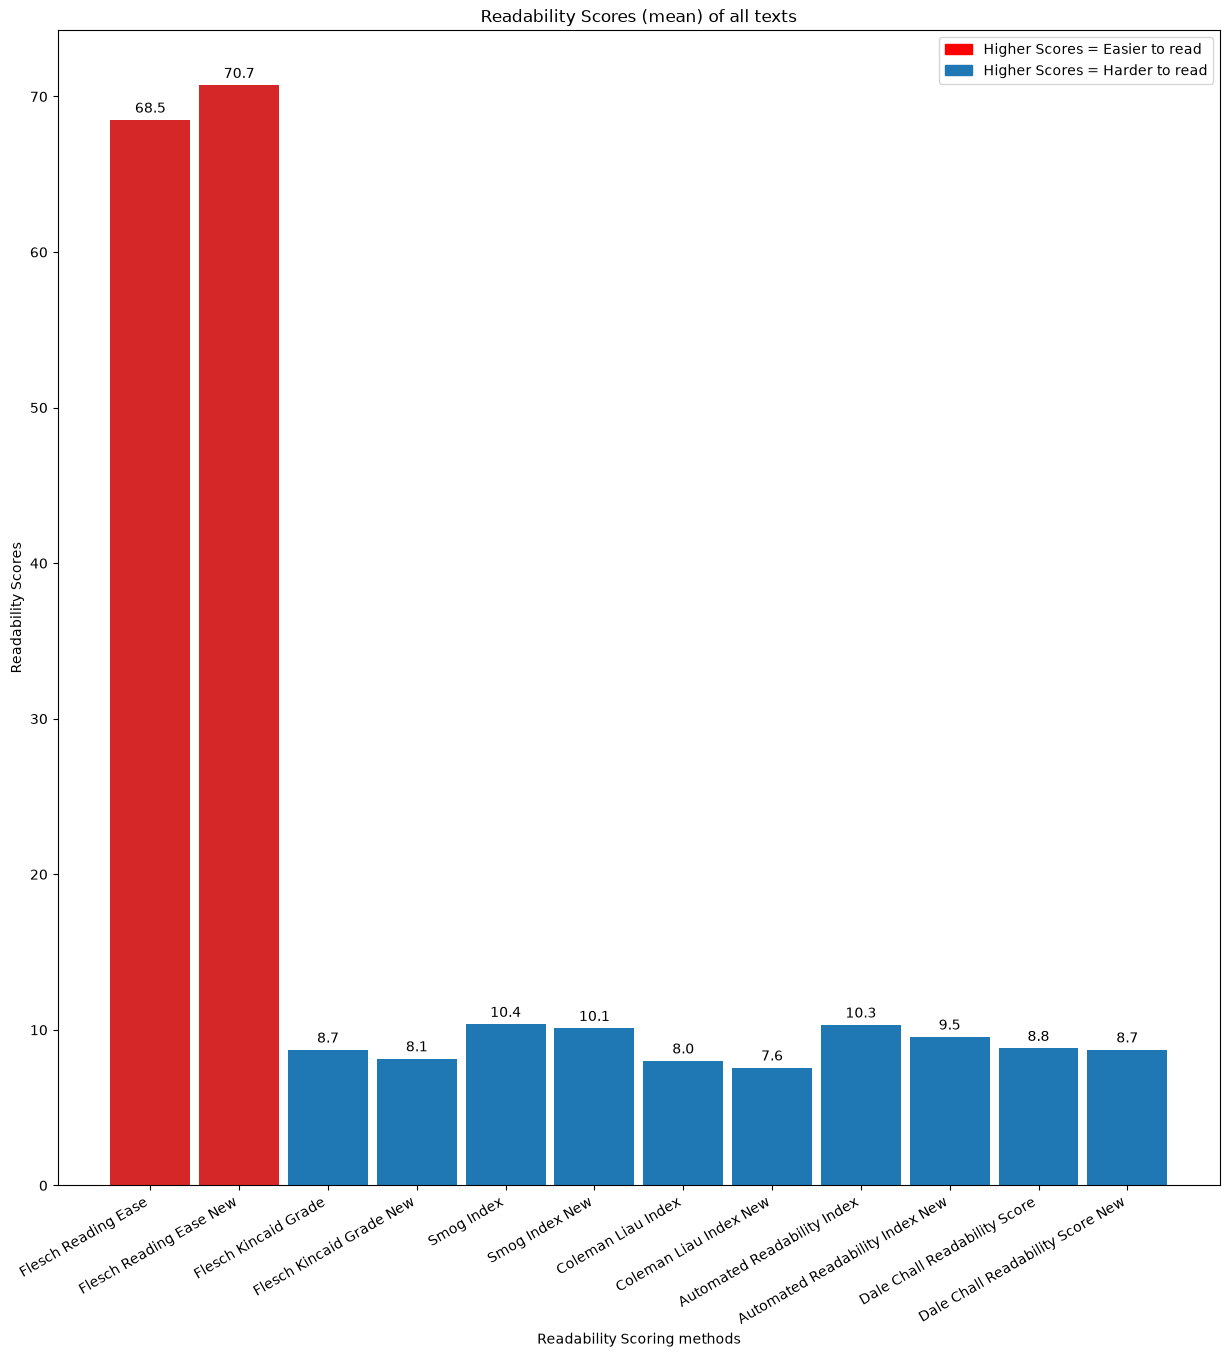

In [4]:
means = df.mean(numeric_only=True)[:12]
means = means.reindex(index = ["flesch_reading_ease", "flesch_reading_ease_new",
                   "flesch_kincaid_grade", "flesch_kincaid_grade_new",
                   "smog_index", "smog_index_new",
                   "coleman_liau_index", "coleman_liau_index_new",
                   "automated_readability_index", "automated_readability_index_new",
                   "dale_chall_readability_score","dale_chall_readability_score_new"])

x = means.index
y = means.values
# bar_labels = ["Flesch reading ease", "Flesch_reading_ease_new",
#                    "flesch_kincaid_grade", "flesch_kincaid_grade_new",
#                    "smog_index", "smog_index_new",
#                    "coleman_liau_index", "coleman_liau_index_new",
#                    "automated_readability_index", "automated_readability_index_new",
#                    "dale_chall_readability_score","dale_chall_readability_score_new"]
# means.reindex(index = ["flesch_reading_ease", "flesch_reading_ease_new",
#                    "flesch_kincaid_grade", "flesch_kincaid_grade_new",
#                    "smog_index", "smog_index_new",
#                    "coleman_liau_index", "coleman_liau_index_new",
#                    "automated_readability_index", "automated_readability_index_new",
#                    "dale_chall_readability_score","dale_chall_readability_score_new"]).plot(kind="bar")
bar_colors = ["tab:red" if item.startswith("flesch_reading") else "tab:blue" for item in means.index]
bar_labels = [item.replace("_", " ").title() for item in means.index]

fig, ax = plt.subplots(figsize=(15, 15))

barchart = ax.bar(x, y, label=bar_labels, color=bar_colors, width=0.9)
plt.xticks(means.index, bar_labels)
ax.tick_params("x", rotation=30, rotation_mode="xtick")
legend_elements = [Patch(facecolor='red', edgecolor='r',
                         label='Color Patch'),
                    Patch(facecolor='tab:blue', edgecolor='tab:blue',
                         label='Color Patch'),]
ax.legend(handles=legend_elements,labels=["Higher Scores = Easier to read", "Higher Scores = Harder to read"])

ax.bar_label(barchart, fmt="%.1f", padding=3)

plt.title("Readability Scores (mean) of all texts")
plt.xlabel("Readability Scoring methods")
plt.ylabel("Readability Scores")
plt.savefig("readability_scores.png")

#### Create Dataframe for Embeddings

In [7]:
means_emb = df.mean(numeric_only=True)[12:18]
means_emb

mean_simple          0.000626
mean_alpha          -0.005154
mean_filtered       -0.004790
mean_simple_new      0.001067
mean_alpha_new      -0.004396
mean_filtered_new   -0.004030
dtype: float64

#### Plot Embeddings

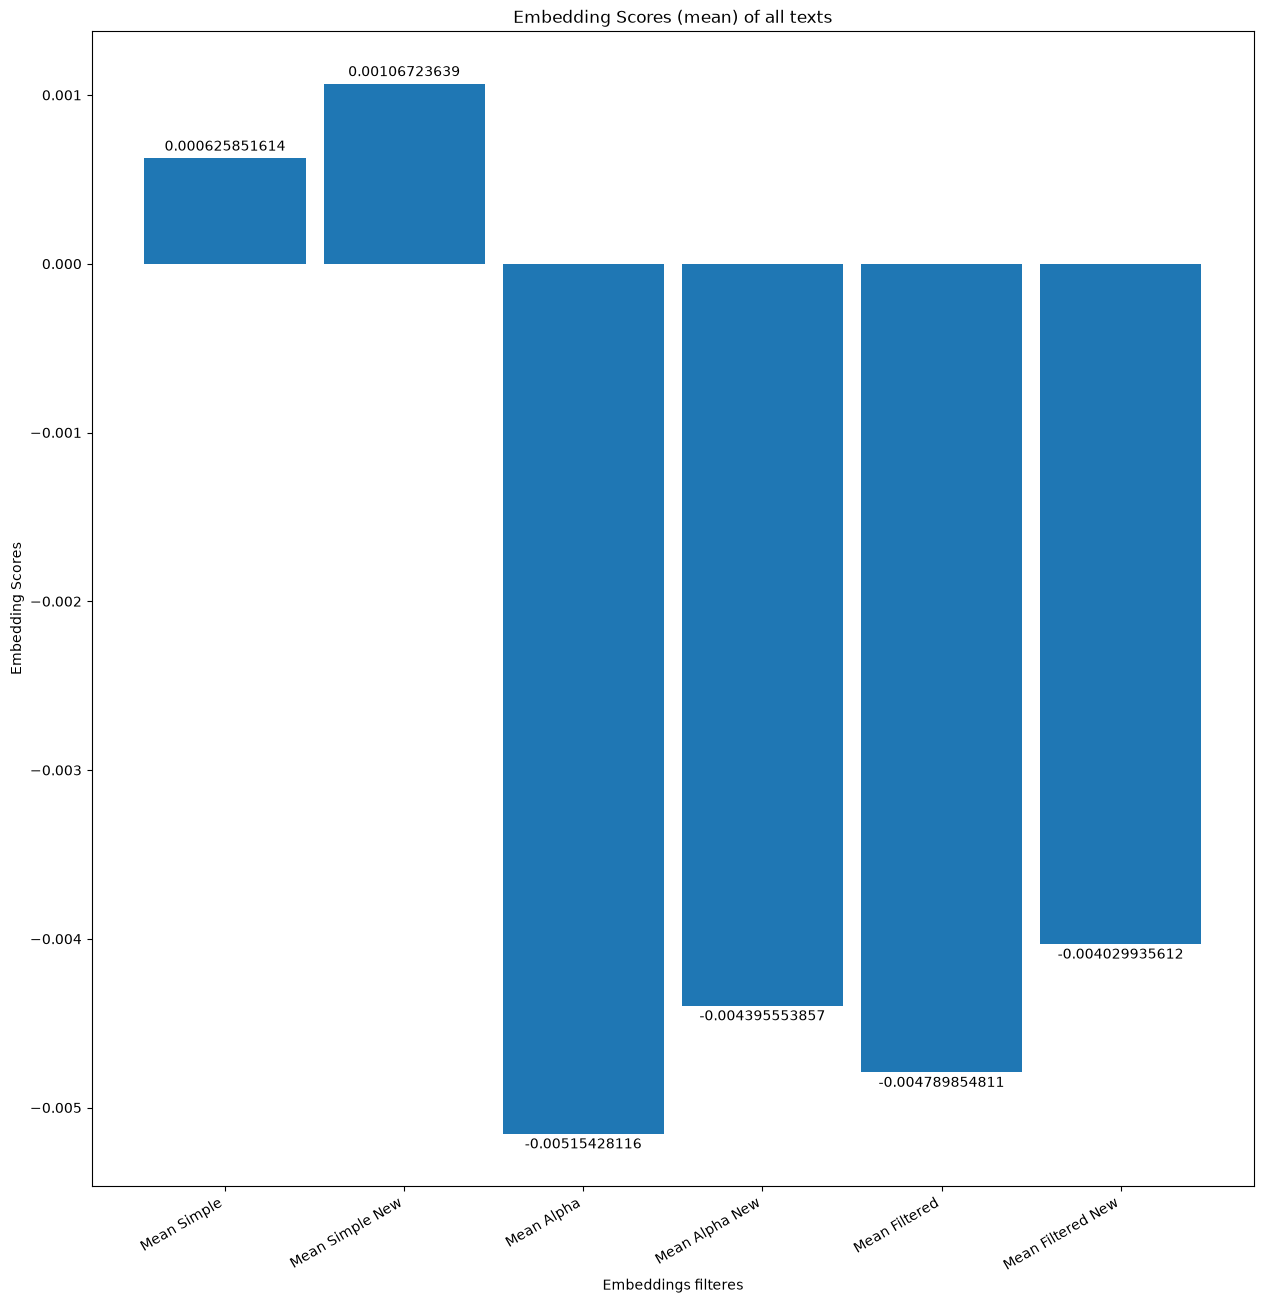

In [8]:

means_emb = means_emb.reindex(index = ["mean_simple", "mean_simple_new", "mean_alpha", "mean_alpha_new", "mean_filtered", "mean_filtered_new"])

x = means_emb.index
y = means_emb.values

bar_labels = [item.replace("_", " ").title() for item in means_emb.index]

fig, ax = plt.subplots(figsize=(15, 15))

barchart = ax.bar(x, y, label=bar_labels, width=0.9)
plt.xticks(means_emb.index, bar_labels)
ax.tick_params("x", rotation=30, rotation_mode="xtick")

ax.bar_label(barchart, labels=means_emb.values, fmt="%.1f", padding=3)

plt.title("Embedding Scores (mean) of all texts")
plt.xlabel("Embeddings filteres")
plt.ylabel("Embedding Scores")
plt.savefig("embedding_scores.png")

## Score Comparisons (extended)

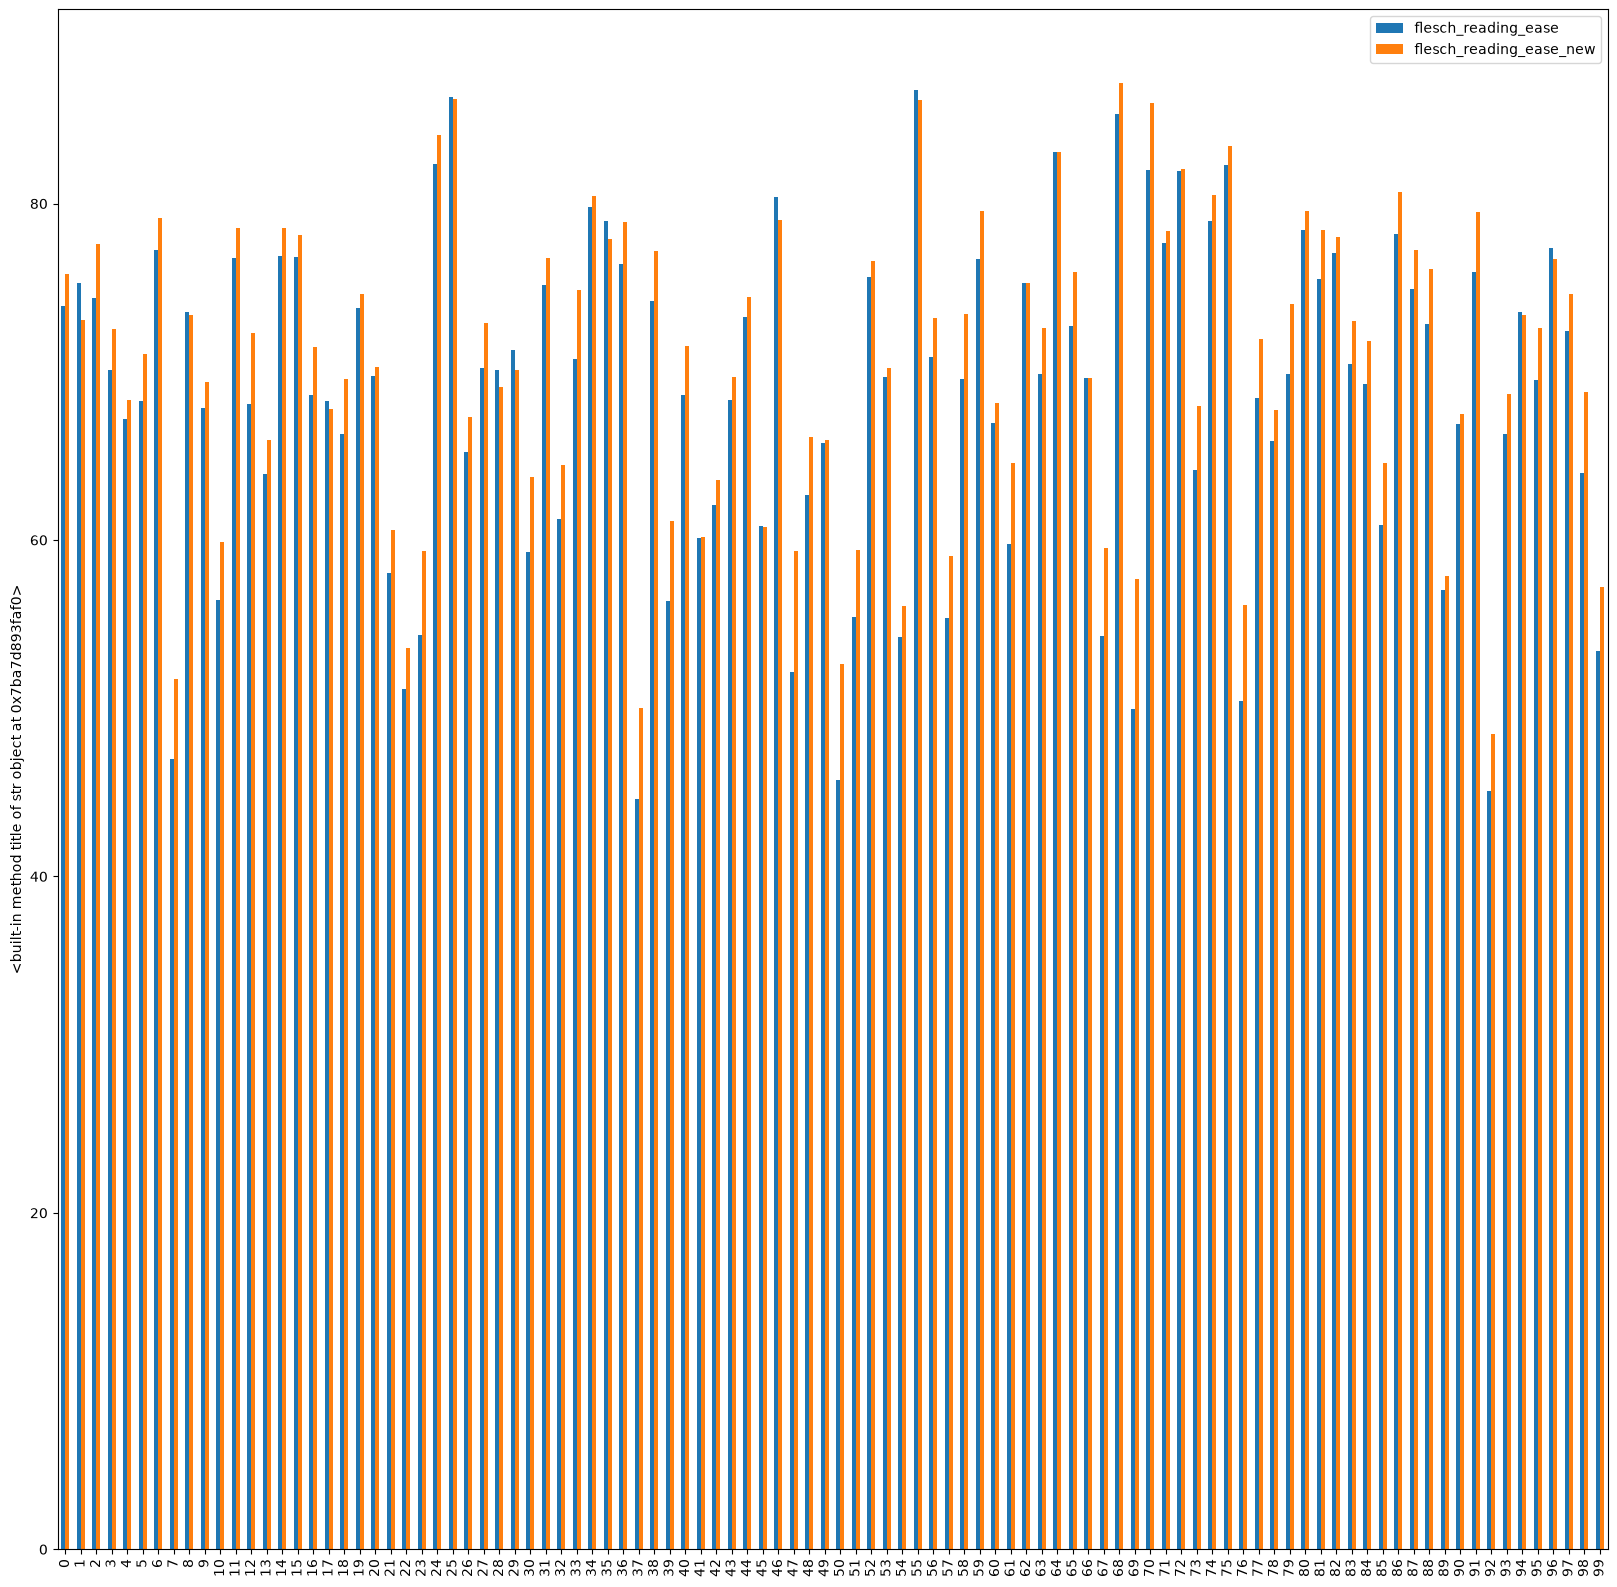

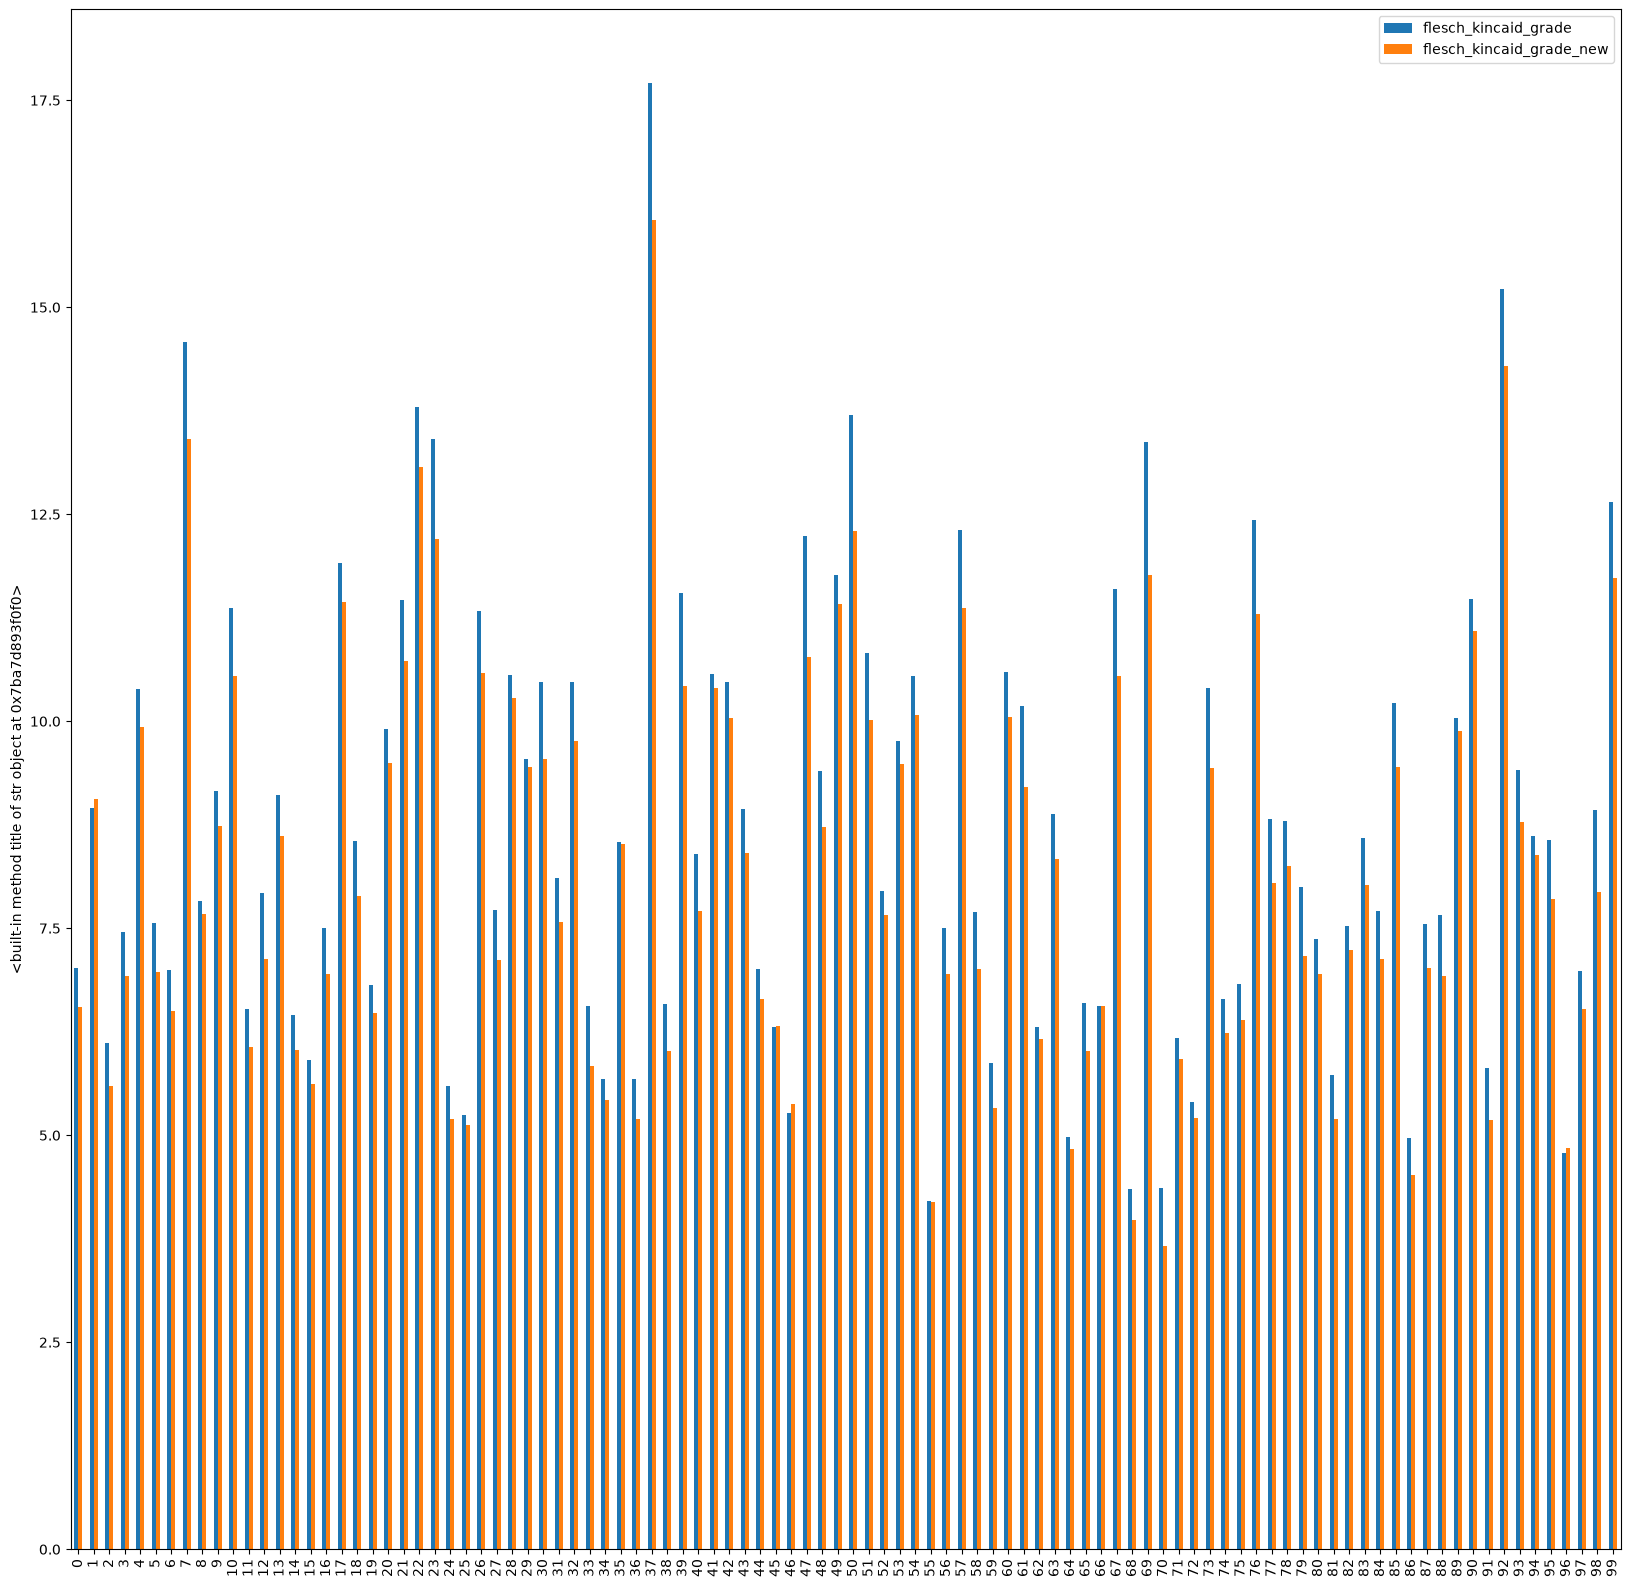

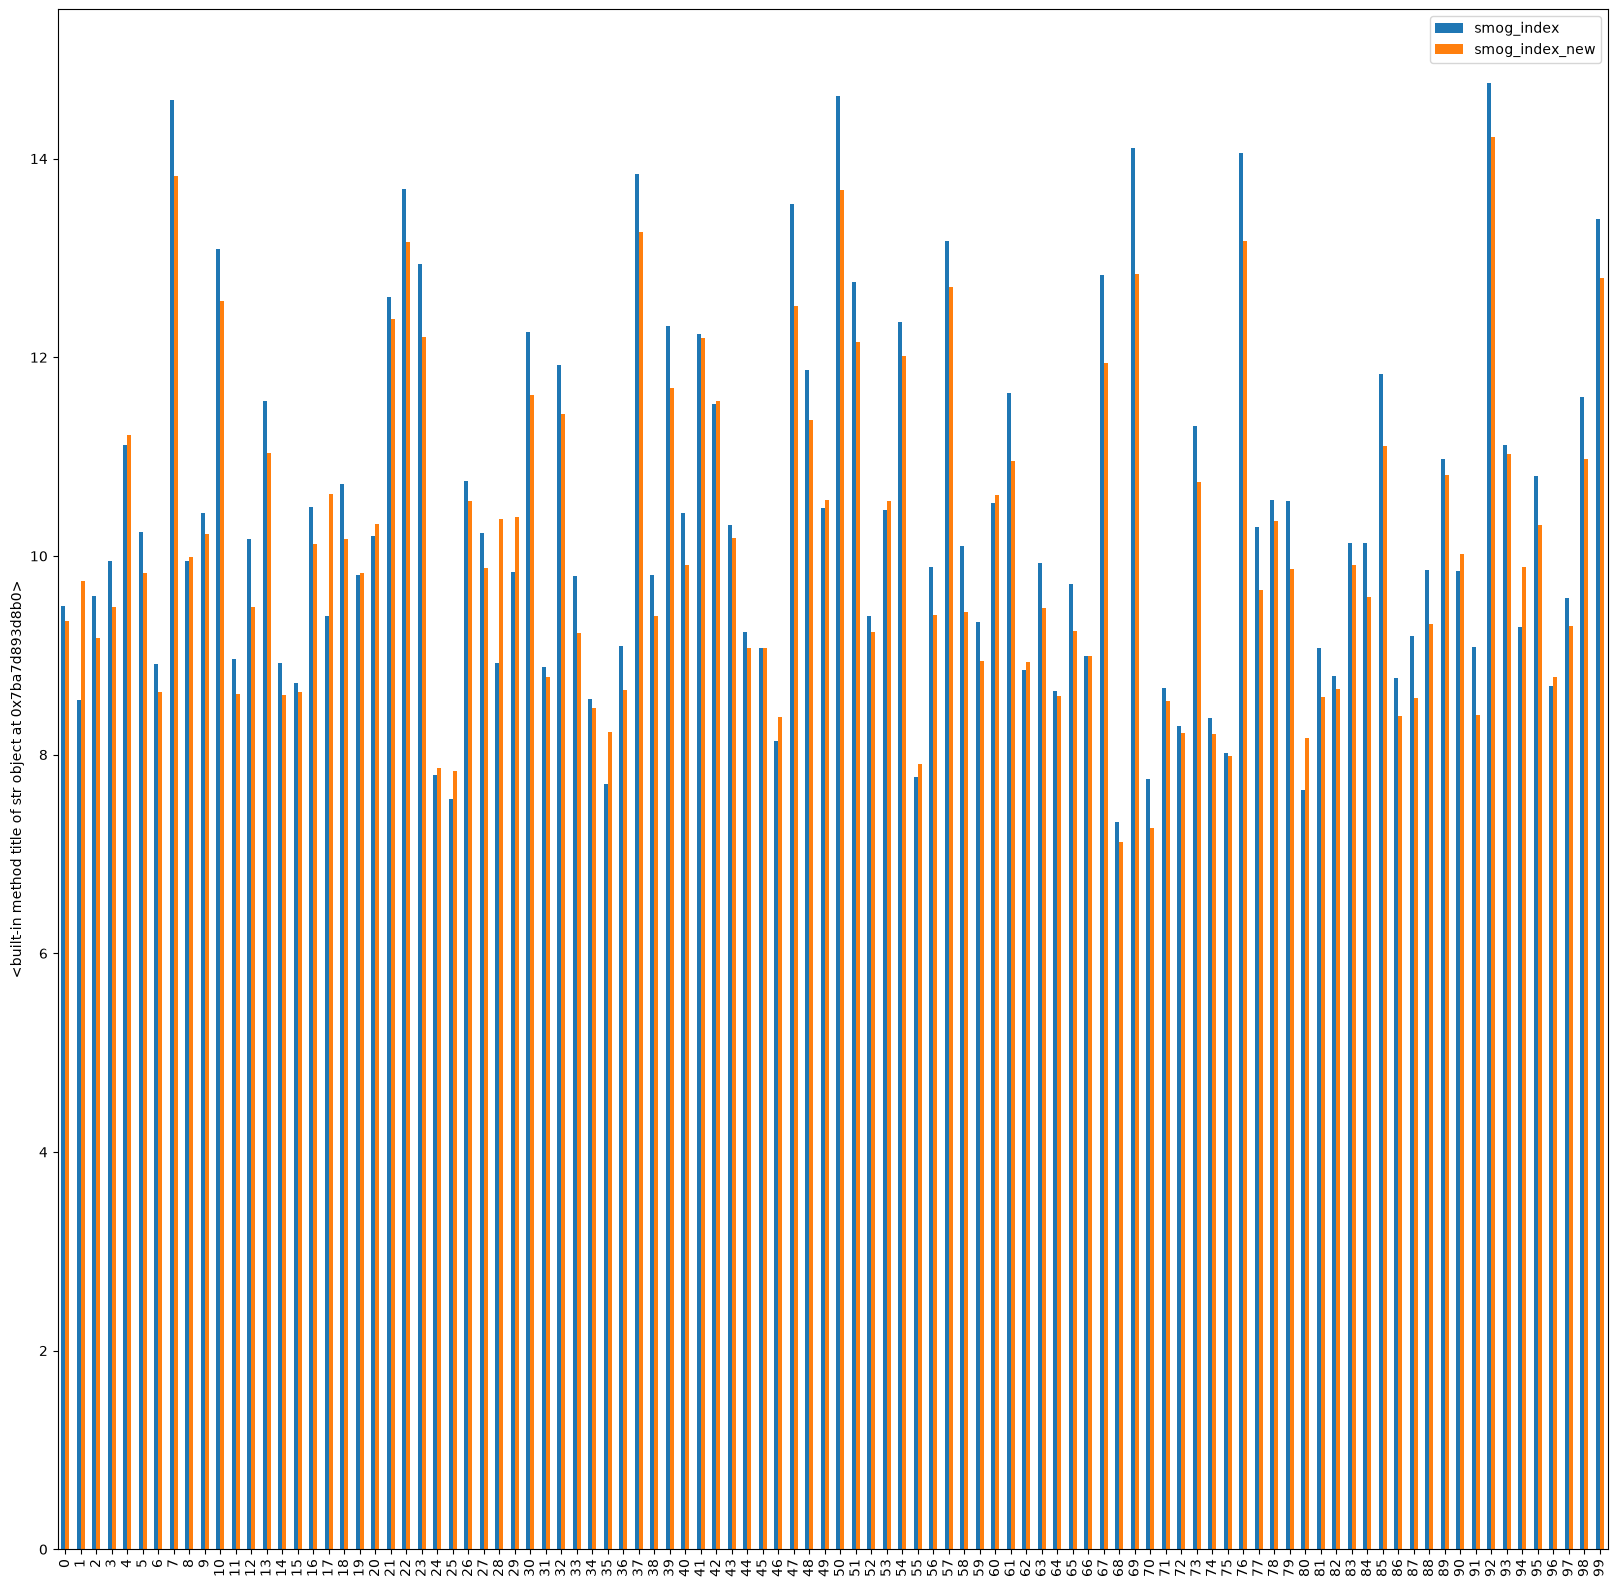

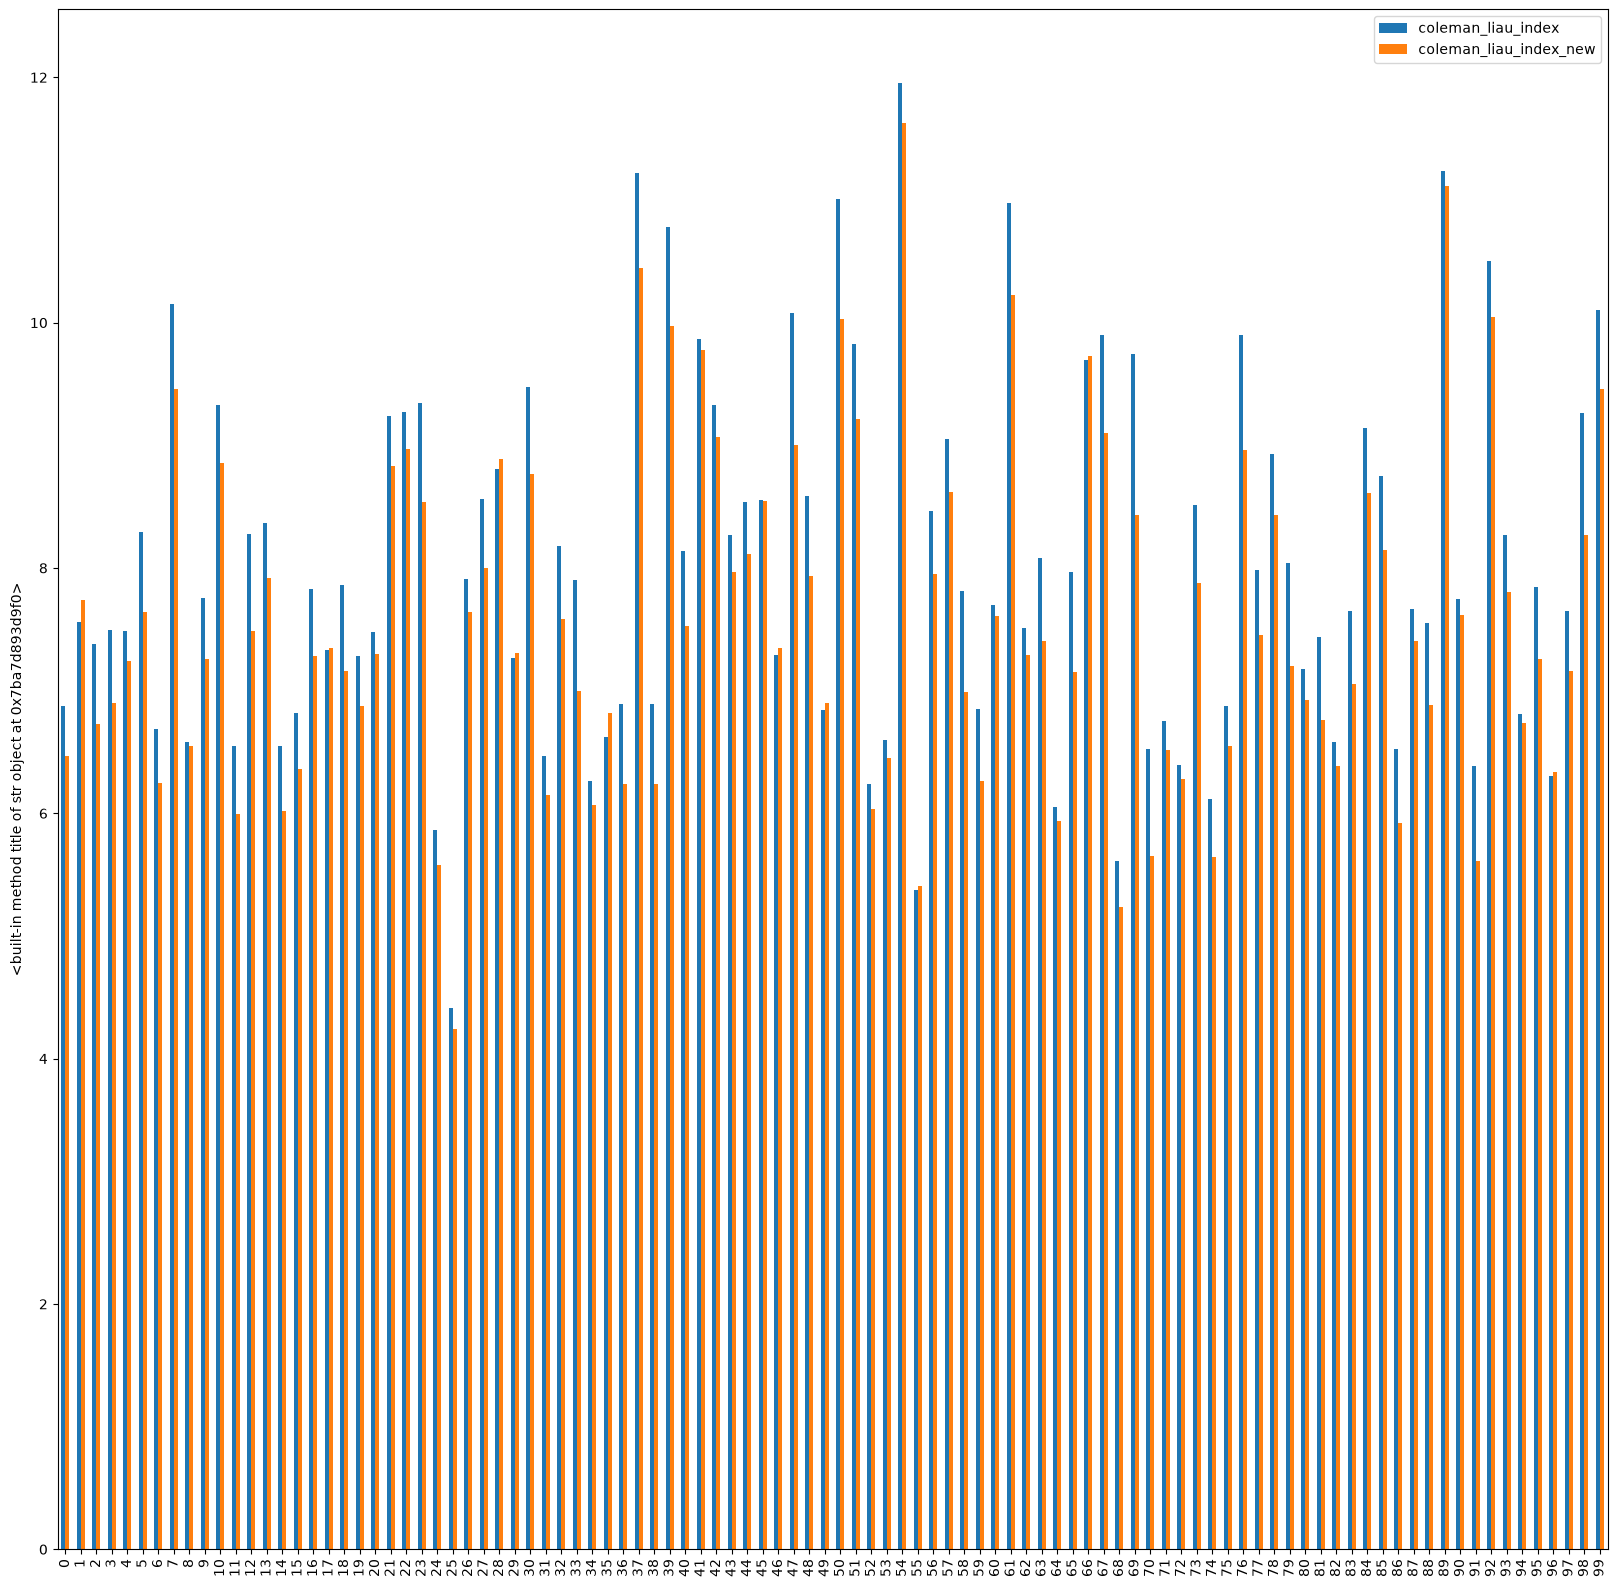

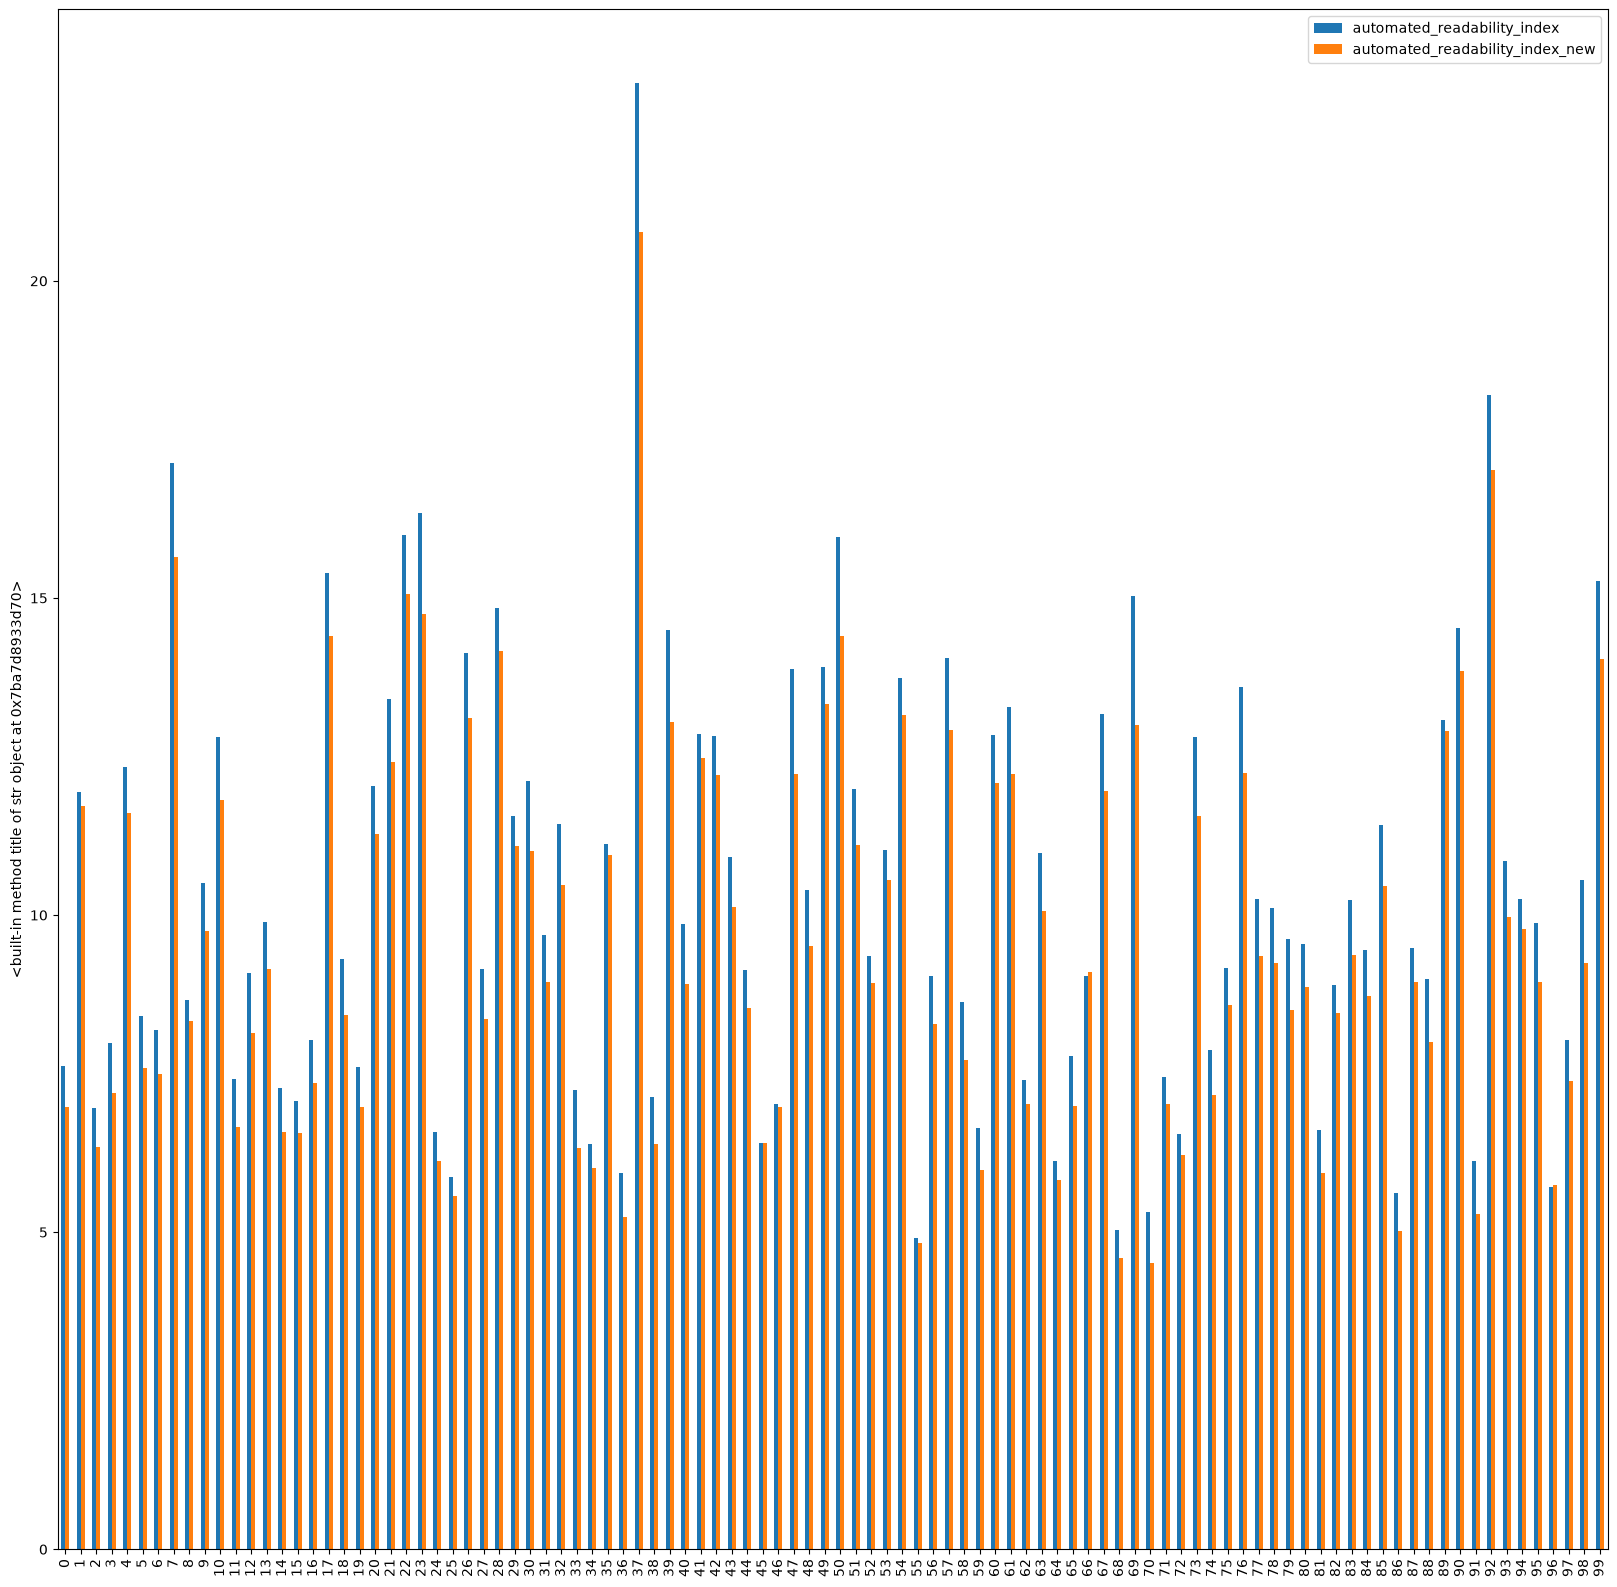

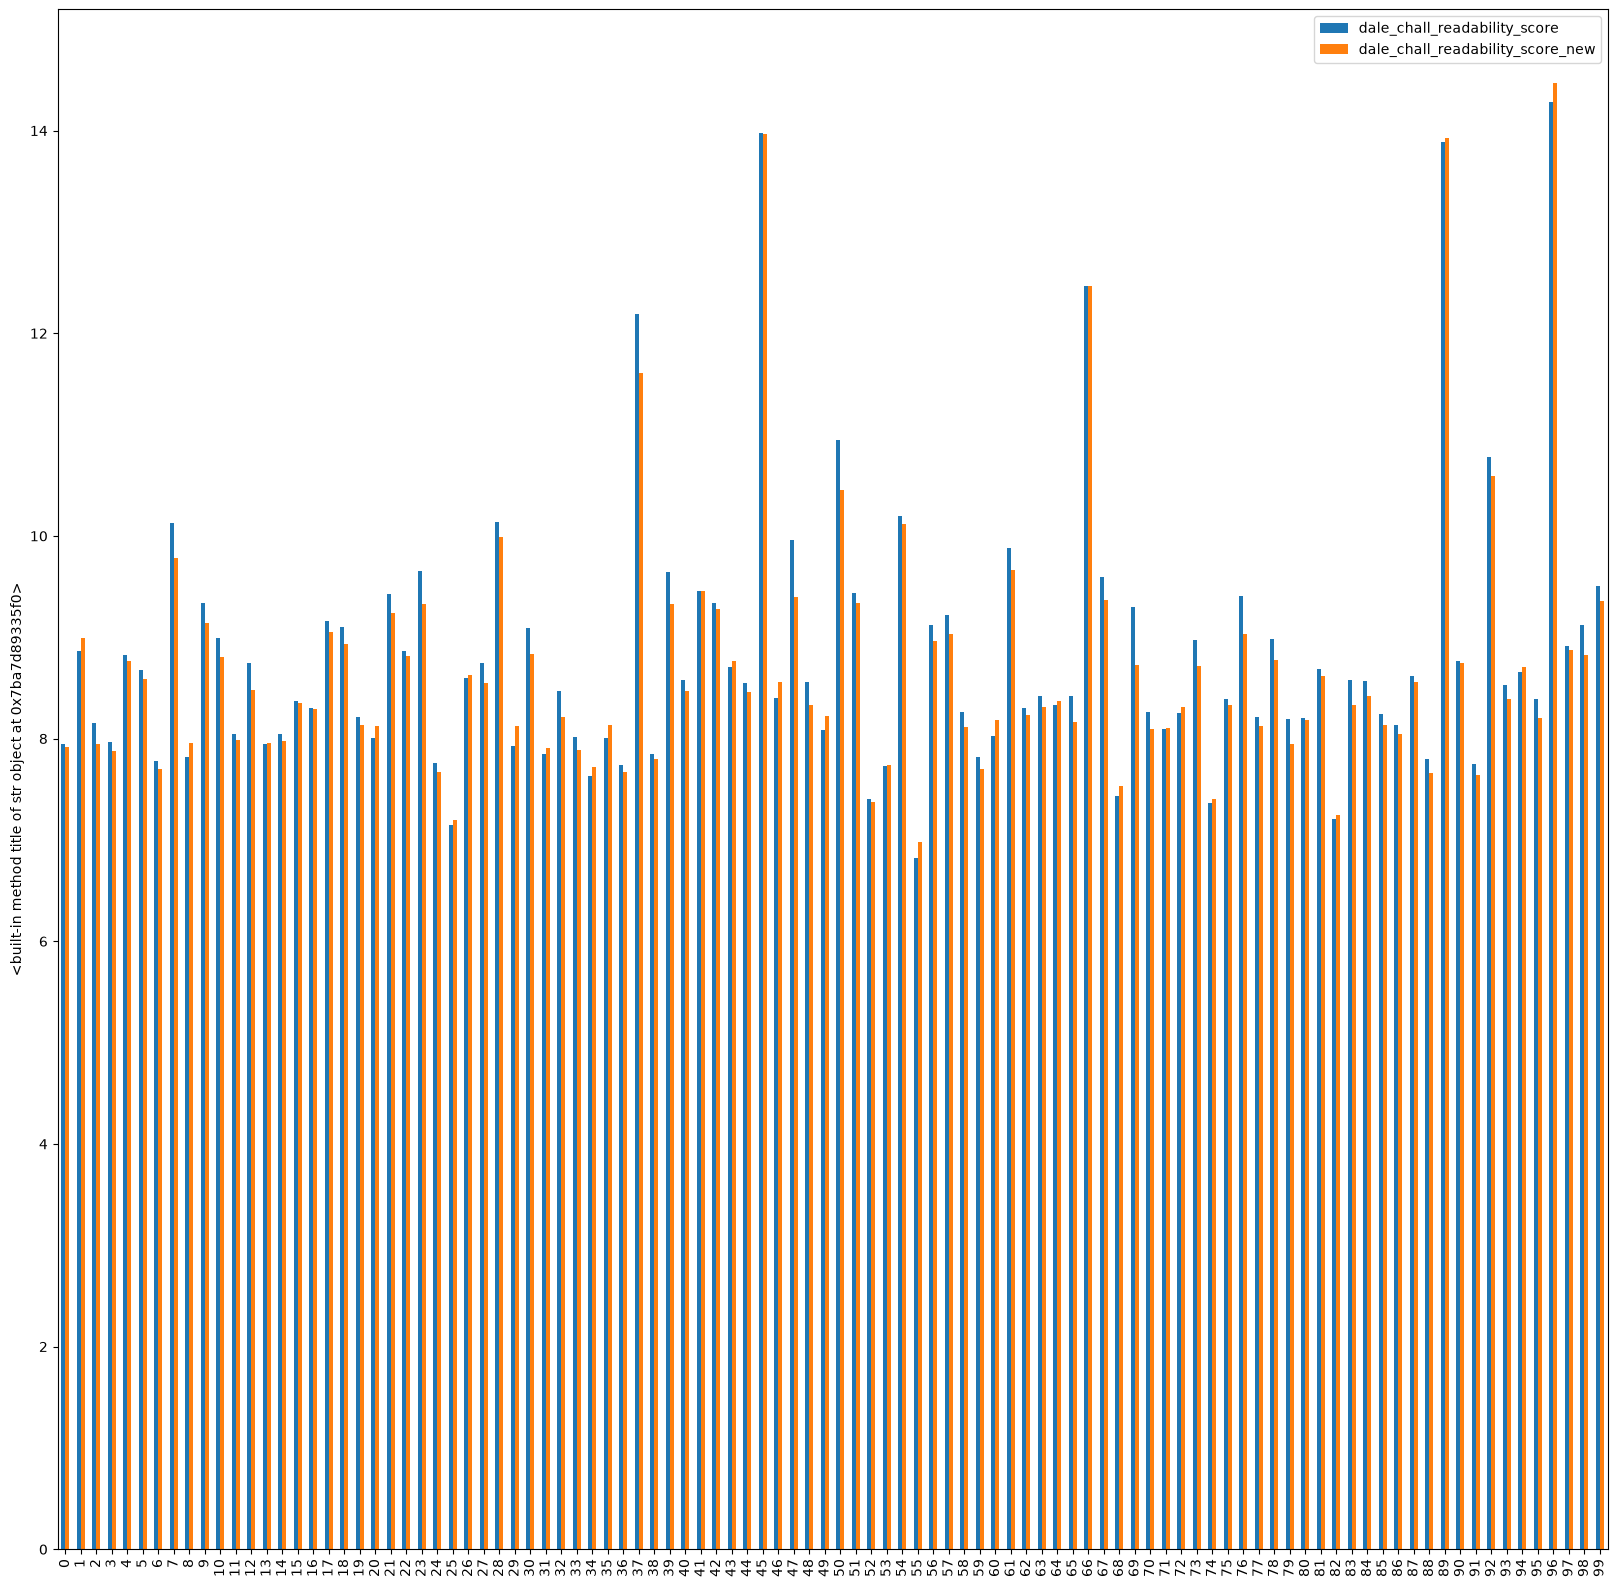

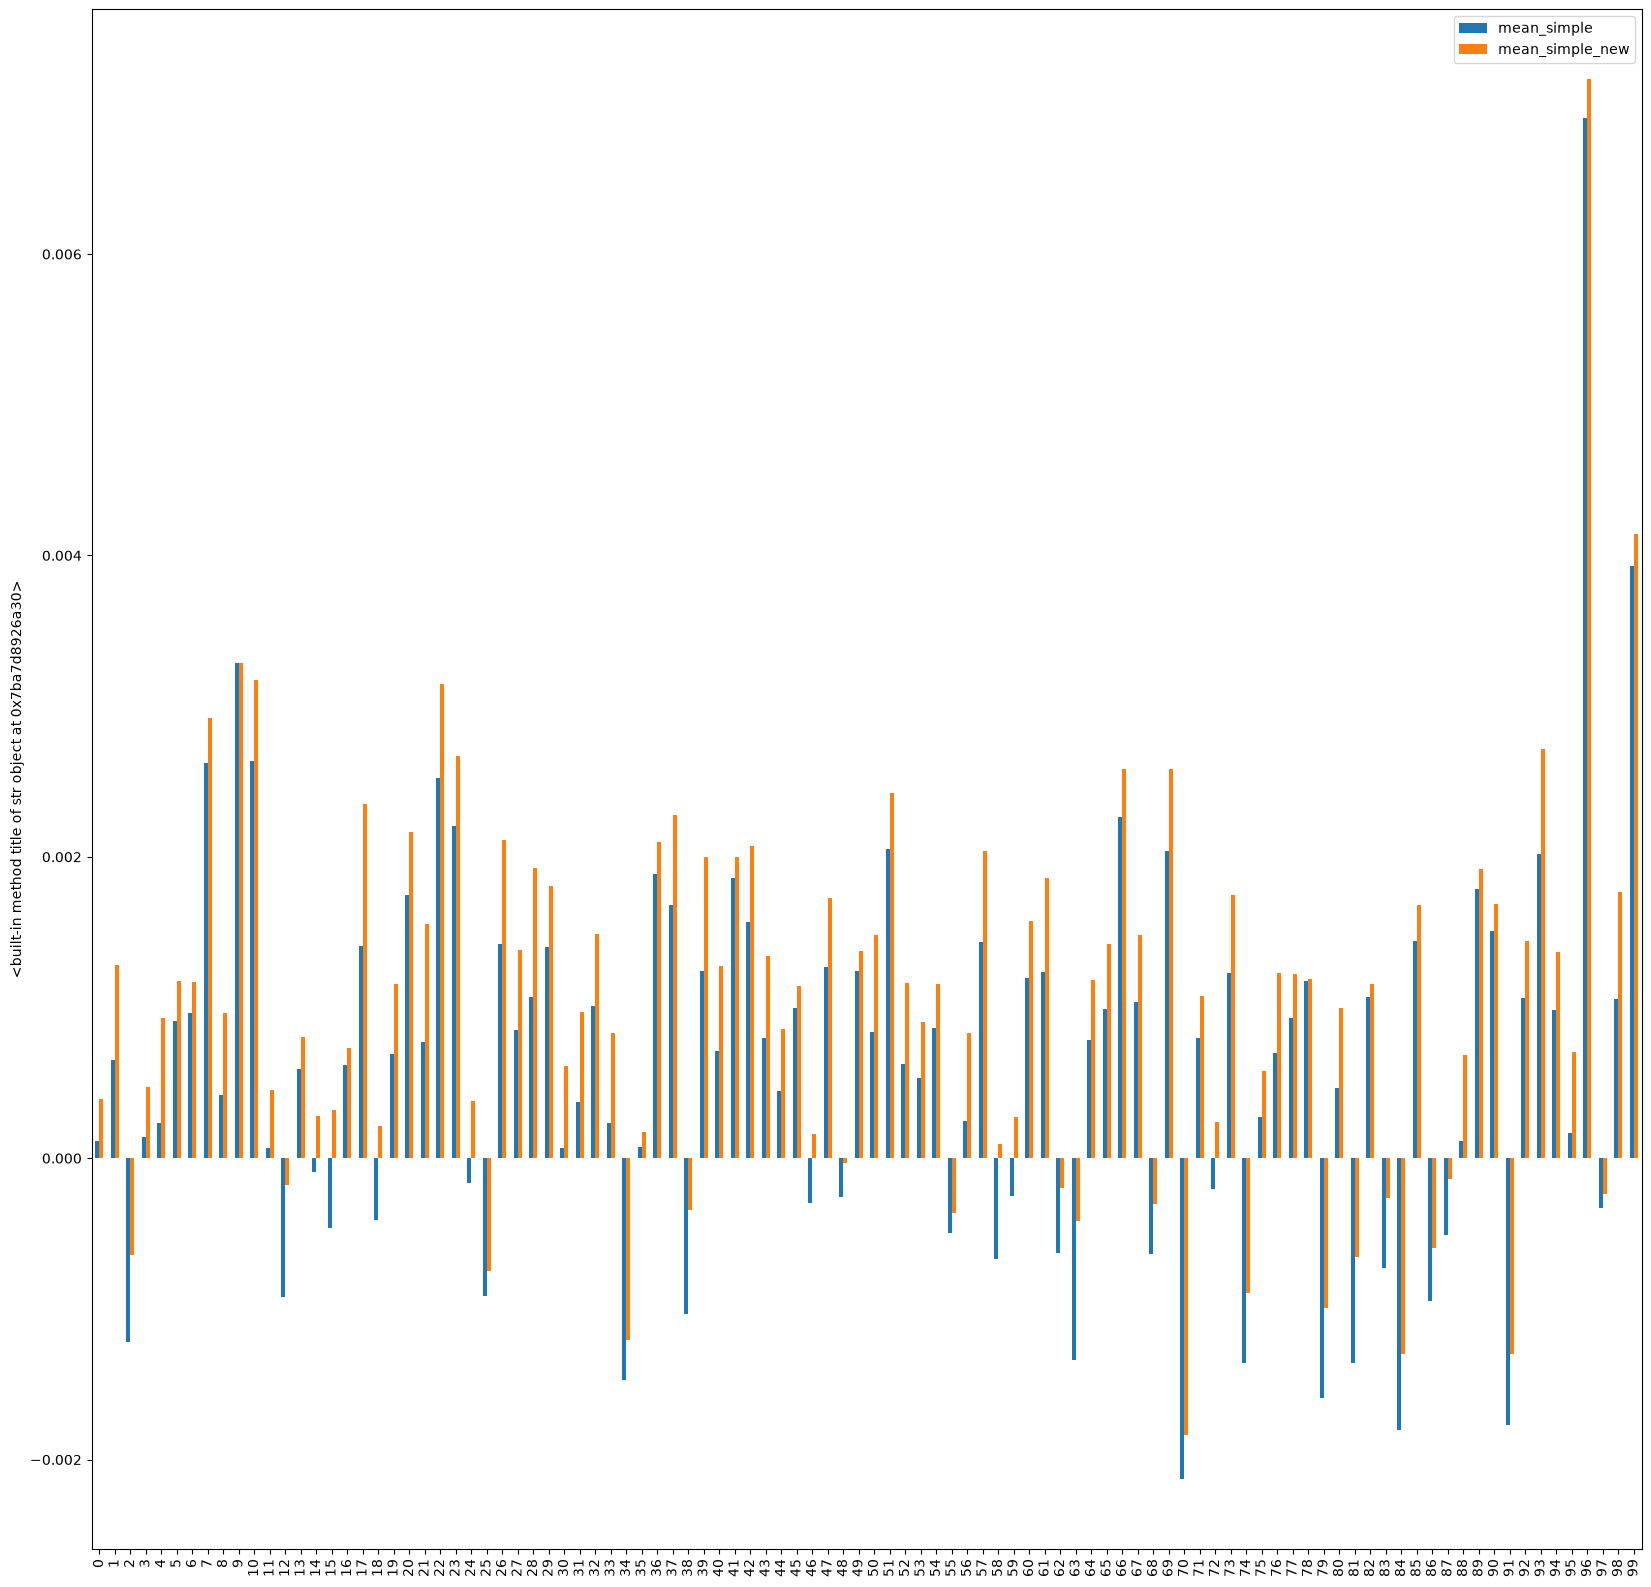

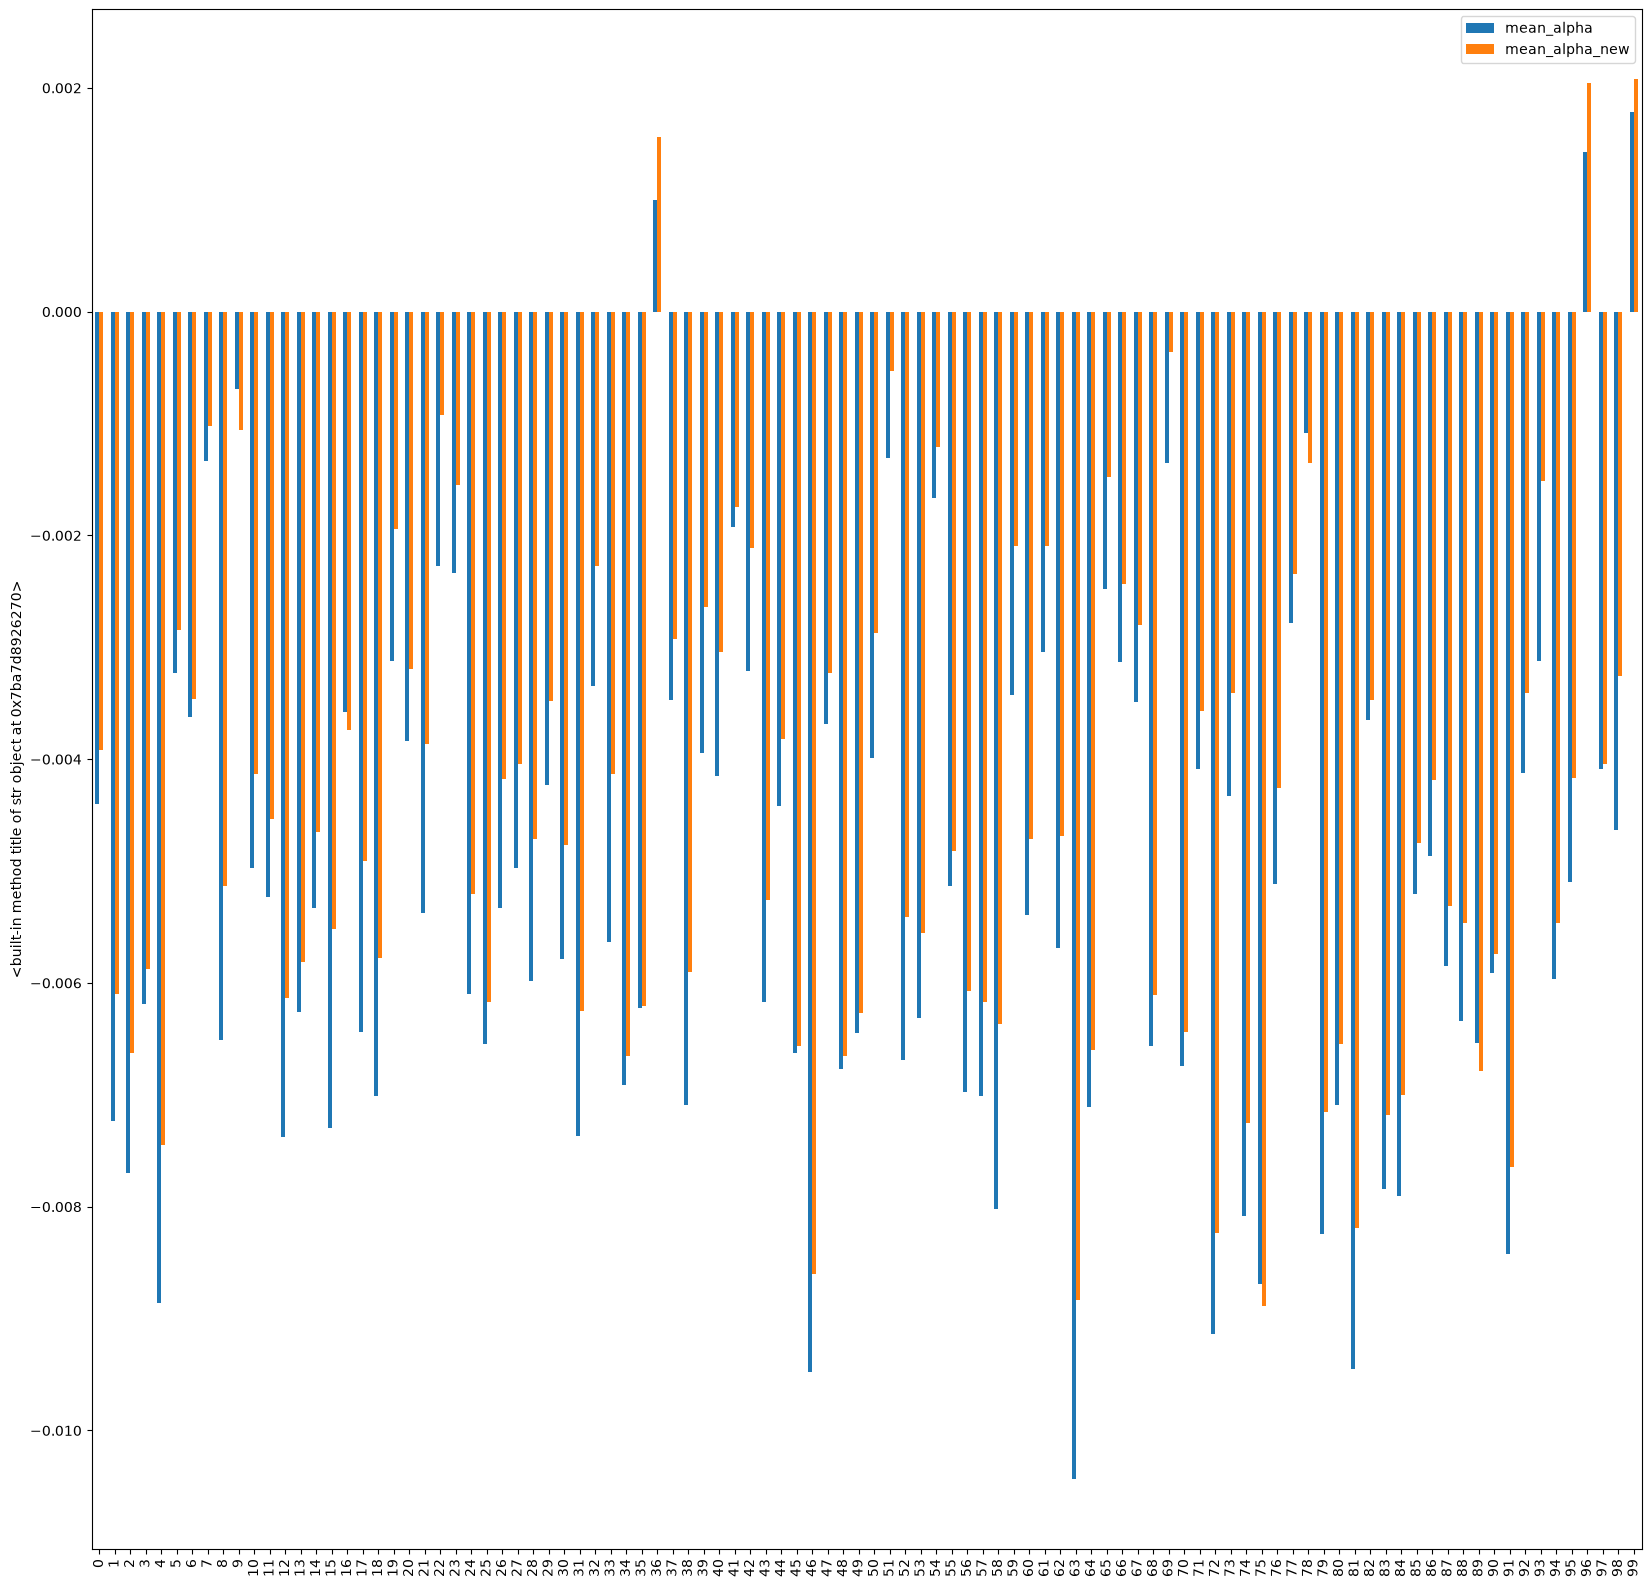

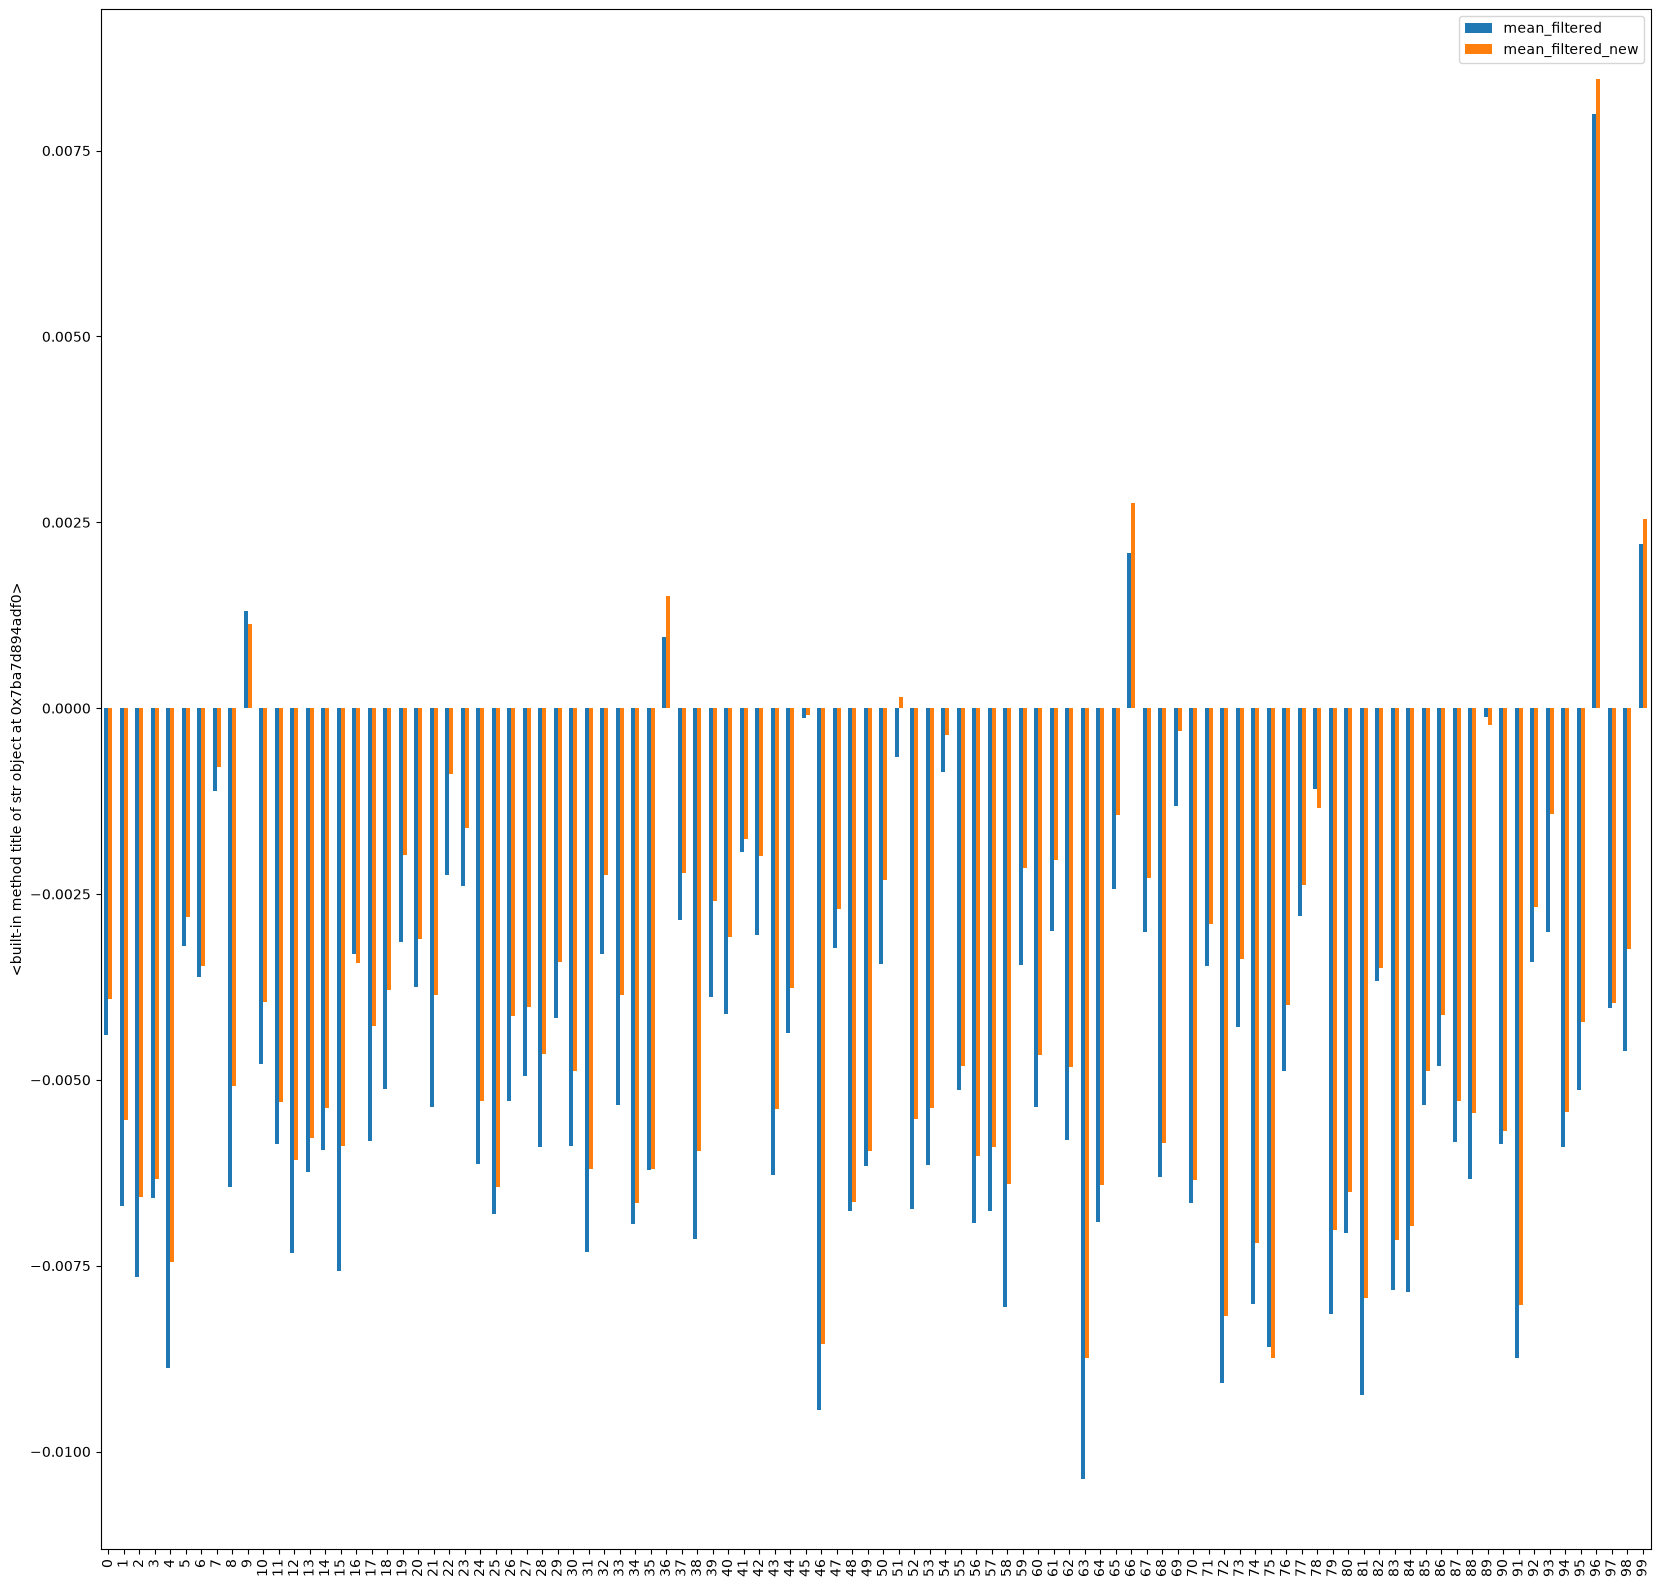

In [10]:
scores = ['flesch_reading_ease',
       'flesch_kincaid_grade', 'smog_index', 'coleman_liau_index',
       'automated_readability_index', 'dale_chall_readability_score', 'mean_simple', 'mean_alpha',
       'mean_filtered']
for score in scores:
    df.plot(y=[f"{score}", f"{score}_new"], kind="bar",figsize=(20,20))
    plt.ylabel(f"{score.title}")
    plt.show()